<a href="https://colab.research.google.com/github/Charan0622/Deeplearning_HW1-/blob/main/019142955_SP26_Homework1_Excellent_Option.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 1 — Excellent Option
## CUDA Core (FP32) vs Tensor Core (TF32) GEMM Benchmark

This notebook measures the performance difference between:
- **Mode 1 (CUDA Core baseline):** FP32 matmul with TF32 **disabled**
- **Mode 2 (Tensor Core):** FP32 matmul with TF32 **enabled**

Implemented in both **PyTorch** and **CUDA C++ (cuBLAS)**.

**Requirements:** A100 GPU runtime (Runtime > Change runtime type > A100)

---
## 1. GPU Verification

In [1]:
import torch
import subprocess

assert torch.cuda.is_available(), "CUDA not available! Change runtime to GPU."

gpu_name = torch.cuda.get_device_name(0)
print(f"GPU: {gpu_name}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version: {torch.version.cuda}")

cap = torch.cuda.get_device_capability(0)
print(f"Compute capability: {cap[0]}.{cap[1]}")
assert cap[0] >= 8, f"Tensor Cores (TF32) require compute capability >= 8.0, got {cap[0]}.{cap[1]}"
print("Tensor Core (TF32) support confirmed.")

GPU: NVIDIA A100-SXM4-40GB
PyTorch version: 2.10.0+cu128
CUDA version: 12.8
Compute capability: 8.0
Tensor Core (TF32) support confirmed.


---
## 2. PyTorch Benchmark: FP32 vs TF32

In [2]:
import torch
import csv
import io

NUM_WARMUP = 50
NUM_ITERS = 200
SIZES = [128, 256, 512, 1024, 2048, 4096, 8192]


def benchmark_fc(M, K, N, use_tf32, num_warmup=NUM_WARMUP, num_iters=NUM_ITERS):
    """Benchmark a single matmul [M,K] x [K,N]. Returns avg latency in ms."""
    torch.backends.cuda.matmul.allow_tf32 = use_tf32
    torch.backends.cudnn.allow_tf32 = use_tf32

    device = torch.device("cuda")
    x = torch.randn(M, K, device=device, dtype=torch.float32)
    weight = torch.randn(K, N, device=device, dtype=torch.float32)

    # Warm-up
    for _ in range(num_warmup):
        _ = torch.mm(x, weight)
    torch.cuda.synchronize()

    # Timed iterations
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    start_event.record()
    for _ in range(num_iters):
        _ = torch.mm(x, weight)
    end_event.record()
    torch.cuda.synchronize()

    total_ms = start_event.elapsed_time(end_event)
    return total_ms / num_iters


def compute_tflops(M, K, N, latency_ms):
    """Throughput in TFLOPS for GEMM [M,K] x [K,N]."""
    flops = 2.0 * M * K * N
    return flops / (latency_ms * 1e-3) / 1e12


print(f"{'Size':>20} | {'FP32 Latency':>14} {'FP32 TFLOPS':>13} | "
      f"{'TF32 Latency':>14} {'TF32 TFLOPS':>13} | {'Speedup':>8}")
print("-" * 100)

pytorch_results = []

for size in SIZES:
    M, K, N = size, size, size

    lat_fp32 = benchmark_fc(M, K, N, use_tf32=False)
    tflops_fp32 = compute_tflops(M, K, N, lat_fp32)

    lat_tf32 = benchmark_fc(M, K, N, use_tf32=True)
    tflops_tf32 = compute_tflops(M, K, N, lat_tf32)

    speedup = lat_fp32 / lat_tf32 if lat_tf32 > 0 else float('inf')

    print(f"{M:>5}x{K:>5}x{N:>5} | "
          f"{lat_fp32:>10.4f} ms {tflops_fp32:>10.2f}   | "
          f"{lat_tf32:>10.4f} ms {tflops_tf32:>10.2f}   | "
          f"{speedup:>6.2f}x")

    pytorch_results.append({
        "M": M, "K": K, "N": N,
        "latency_fp32_ms": lat_fp32, "tflops_fp32": tflops_fp32,
        "latency_tf32_ms": lat_tf32, "tflops_tf32": tflops_tf32,
        "speedup": speedup,
    })

# Save CSV
with open("results_pytorch.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=pytorch_results[0].keys())
    writer.writeheader()
    writer.writerows(pytorch_results)

print("\nSaved to results_pytorch.csv")

                Size |   FP32 Latency   FP32 TFLOPS |   TF32 Latency   TF32 TFLOPS |  Speedup
----------------------------------------------------------------------------------------------------
  128x  128x  128 |     0.0148 ms       0.28   |     0.0160 ms       0.26   |   0.93x
  256x  256x  256 |     0.0183 ms       1.84   |     0.0193 ms       1.74   |   0.95x
  512x  512x  512 |     0.0302 ms       8.88   |     0.0158 ms      17.00   |   1.92x
 1024x 1024x 1024 |     0.1417 ms      15.16   |     0.0350 ms      61.40   |   4.05x
 2048x 2048x 2048 |     0.9855 ms      17.43   |     0.1696 ms     101.30   |   5.81x
 4096x 4096x 4096 |     7.2276 ms      19.02   |     1.1147 ms     123.30   |   6.48x
 8192x 8192x 8192 |    57.3924 ms      19.16   |     8.5230 ms     129.00   |   6.73x

Saved to results_pytorch.csv


---
## 3. CUDA C++ cuBLAS Benchmark: cublasSgemm vs cublasGemmEx (TF32)

In [3]:
%%writefile benchmark_cublas.cu
#include <cstdio>
#include <cstdlib>
#include <cmath>
#include <vector>
#include <cuda_runtime.h>
#include <cublas_v2.h>

#define CHECK_CUDA(call) do { \
    cudaError_t err = (call); \
    if (err != cudaSuccess) { \
        fprintf(stderr, "CUDA error at %s:%d: %s\n", __FILE__, __LINE__, cudaGetErrorString(err)); \
        exit(EXIT_FAILURE); \
    } \
} while (0)

#define CHECK_CUBLAS(call) do { \
    cublasStatus_t stat = (call); \
    if (stat != CUBLAS_STATUS_SUCCESS) { \
        fprintf(stderr, "cuBLAS error at %s:%d: %d\n", __FILE__, __LINE__, (int)stat); \
        exit(EXIT_FAILURE); \
    } \
} while (0)

static double compute_tflops(int M, int K, int N, float latency_ms) {
    double flops = 2.0 * M * K * N;
    return flops / (latency_ms * 1e-3) / 1e12;
}

// FP32 baseline using cublasSgemm with tensor cores disabled
static float bench_sgemm(cublasHandle_t handle, int M, int K, int N,
                          const float* d_A, const float* d_B, float* d_C,
                          int num_warmup, int num_iters) {
    float alpha = 1.0f, beta = 0.0f;
    CHECK_CUBLAS(cublasSetMathMode(handle, CUBLAS_DEFAULT_MATH));

    for (int i = 0; i < num_warmup; i++)
        CHECK_CUBLAS(cublasSgemm(handle, CUBLAS_OP_N, CUBLAS_OP_N,
                                 N, M, K, &alpha, d_B, N, d_A, K, &beta, d_C, N));
    CHECK_CUDA(cudaDeviceSynchronize());

    cudaEvent_t start, stop;
    CHECK_CUDA(cudaEventCreate(&start));
    CHECK_CUDA(cudaEventCreate(&stop));
    CHECK_CUDA(cudaEventRecord(start));
    for (int i = 0; i < num_iters; i++)
        CHECK_CUBLAS(cublasSgemm(handle, CUBLAS_OP_N, CUBLAS_OP_N,
                                 N, M, K, &alpha, d_B, N, d_A, K, &beta, d_C, N));
    CHECK_CUDA(cudaEventRecord(stop));
    CHECK_CUDA(cudaEventSynchronize(stop));

    float total_ms = 0.0f;
    CHECK_CUDA(cudaEventElapsedTime(&total_ms, start, stop));
    CHECK_CUDA(cudaEventDestroy(start));
    CHECK_CUDA(cudaEventDestroy(stop));
    return total_ms / num_iters;
}

// TF32 Tensor Core path using cublasGemmEx
static float bench_tf32(cublasHandle_t handle, int M, int K, int N,
                         const float* d_A, const float* d_B, float* d_C,
                         int num_warmup, int num_iters) {
    float alpha = 1.0f, beta = 0.0f;
    CHECK_CUBLAS(cublasSetMathMode(handle, CUBLAS_TF32_TENSOR_OP_MATH));

    for (int i = 0; i < num_warmup; i++)
        CHECK_CUBLAS(cublasGemmEx(handle, CUBLAS_OP_N, CUBLAS_OP_N,
                                  N, M, K, &alpha,
                                  d_B, CUDA_R_32F, N,
                                  d_A, CUDA_R_32F, K,
                                  &beta,
                                  d_C, CUDA_R_32F, N,
                                  CUBLAS_COMPUTE_32F_FAST_TF32,
                                  CUBLAS_GEMM_DEFAULT_TENSOR_OP));
    CHECK_CUDA(cudaDeviceSynchronize());

    cudaEvent_t start, stop;
    CHECK_CUDA(cudaEventCreate(&start));
    CHECK_CUDA(cudaEventCreate(&stop));
    CHECK_CUDA(cudaEventRecord(start));
    for (int i = 0; i < num_iters; i++)
        CHECK_CUBLAS(cublasGemmEx(handle, CUBLAS_OP_N, CUBLAS_OP_N,
                                  N, M, K, &alpha,
                                  d_B, CUDA_R_32F, N,
                                  d_A, CUDA_R_32F, K,
                                  &beta,
                                  d_C, CUDA_R_32F, N,
                                  CUBLAS_COMPUTE_32F_FAST_TF32,
                                  CUBLAS_GEMM_DEFAULT_TENSOR_OP));
    CHECK_CUDA(cudaEventRecord(stop));
    CHECK_CUDA(cudaEventSynchronize(stop));

    float total_ms = 0.0f;
    CHECK_CUDA(cudaEventElapsedTime(&total_ms, start, stop));
    CHECK_CUDA(cudaEventDestroy(start));
    CHECK_CUDA(cudaEventDestroy(stop));
    return total_ms / num_iters;
}

int main() {
    int num_warmup = 50;
    int num_iters  = 200;

    cudaDeviceProp prop;
    CHECK_CUDA(cudaGetDeviceProperties(&prop, 0));
    printf("GPU: %s (Compute %d.%d)\n", prop.name, prop.major, prop.minor);
    printf("Warm-up: %d, Timed iters: %d\n", num_warmup, num_iters);
    printf("------------------------------------------------------------------------\n");

    cublasHandle_t handle;
    CHECK_CUBLAS(cublasCreate(&handle));

    int sizes[] = {128, 256, 512, 1024, 2048, 4096, 8192};
    int num_sizes = sizeof(sizes) / sizeof(sizes[0]);

    // Print CSV header to stdout for capture
    printf("CSV_START\n");
    printf("M,K,N,latency_fp32_ms,tflops_fp32,latency_tf32_ms,tflops_tf32,speedup\n");

    for (int s = 0; s < num_sizes; s++) {
        int M = sizes[s], K = sizes[s], N = sizes[s];

        float *d_A, *d_B, *d_C;
        size_t sA = (size_t)M * K * sizeof(float);
        size_t sB = (size_t)K * N * sizeof(float);
        size_t sC = (size_t)M * N * sizeof(float);
        CHECK_CUDA(cudaMalloc(&d_A, sA));
        CHECK_CUDA(cudaMalloc(&d_B, sB));
        CHECK_CUDA(cudaMalloc(&d_C, sC));

        std::vector<float> h_A(M * K), h_B(K * N);
        for (int i = 0; i < M * K; i++) h_A[i] = (float)rand() / RAND_MAX;
        for (int i = 0; i < K * N; i++) h_B[i] = (float)rand() / RAND_MAX;
        CHECK_CUDA(cudaMemcpy(d_A, h_A.data(), sA, cudaMemcpyHostToDevice));
        CHECK_CUDA(cudaMemcpy(d_B, h_B.data(), sB, cudaMemcpyHostToDevice));

        float lat_fp32 = bench_sgemm(handle, M, K, N, d_A, d_B, d_C, num_warmup, num_iters);
        double tf_fp32 = compute_tflops(M, K, N, lat_fp32);

        float lat_tf32 = bench_tf32(handle, M, K, N, d_A, d_B, d_C, num_warmup, num_iters);
        double tf_tf32 = compute_tflops(M, K, N, lat_tf32);

        double speedup = (lat_tf32 > 0) ? lat_fp32 / lat_tf32 : 0.0;

        printf("%d,%d,%d,%.6f,%.4f,%.6f,%.4f,%.4f\n",
               M, K, N, lat_fp32, tf_fp32, lat_tf32, tf_tf32, speedup);

        // Also print human-readable to stderr
        fprintf(stderr, "Size %5dx%5dx%5d | FP32: %8.4f ms (%7.2f TFLOPS) | "
               "TF32: %8.4f ms (%7.2f TFLOPS) | Speedup: %.2fx\n",
               M, K, N, lat_fp32, tf_fp32, lat_tf32, tf_tf32, speedup);

        CHECK_CUDA(cudaFree(d_A));
        CHECK_CUDA(cudaFree(d_B));
        CHECK_CUDA(cudaFree(d_C));
    }
    printf("CSV_END\n");

    CHECK_CUBLAS(cublasDestroy(handle));
    return 0;
}

Writing benchmark_cublas.cu


In [4]:
# Compile the CUDA benchmark
!nvcc -O3 -lcublas -arch=sm_80 -o benchmark_cublas benchmark_cublas.cu
print("Compilation successful!")

Compilation successful!


In [5]:
import subprocess
import csv
import io

# Run the cuBLAS benchmark and capture output
result = subprocess.run(["./benchmark_cublas"], capture_output=True, text=True, timeout=300)

# Print human-readable output (stderr)
print(result.stderr)

# Parse CSV from stdout
stdout = result.stdout
csv_text = stdout.split("CSV_START\n")[1].split("CSV_END")[0]

cublas_results = []
reader = csv.DictReader(io.StringIO(csv_text))
for row in reader:
    cublas_results.append({k: float(v) for k, v in row.items()})

# Save CSV
with open("results_cublas.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=cublas_results[0].keys())
    writer.writeheader()
    writer.writerows(cublas_results)

print(f"\nParsed {len(cublas_results)} rows, saved to results_cublas.csv")

Size   128x  128x  128 | FP32:   0.0076 ms (   0.55 TFLOPS) | TF32:   0.0085 ms (   0.49 TFLOPS) | Speedup: 0.89x
Size   256x  256x  256 | FP32:   0.0123 ms (   2.74 TFLOPS) | TF32:   0.0125 ms (   2.69 TFLOPS) | Speedup: 0.98x
Size   512x  512x  512 | FP32:   0.0274 ms (   9.81 TFLOPS) | TF32:   0.0107 ms (  25.13 TFLOPS) | Speedup: 2.56x
Size  1024x 1024x 1024 | FP32:   0.1294 ms (  16.59 TFLOPS) | TF32:   0.0318 ms (  67.49 TFLOPS) | Speedup: 4.07x
Size  2048x 2048x 2048 | FP32:   0.9746 ms (  17.63 TFLOPS) | TF32:   0.1676 ms ( 102.51 TFLOPS) | Speedup: 5.81x
Size  4096x 4096x 4096 | FP32:   7.2273 ms (  19.02 TFLOPS) | TF32:   1.0786 ms ( 127.42 TFLOPS) | Speedup: 6.70x
Size  8192x 8192x 8192 | FP32:  57.3717 ms (  19.16 TFLOPS) | TF32:   8.2666 ms ( 133.01 TFLOPS) | Speedup: 6.94x


Parsed 7 rows, saved to results_cublas.csv


---
## 4. Comparison Plots

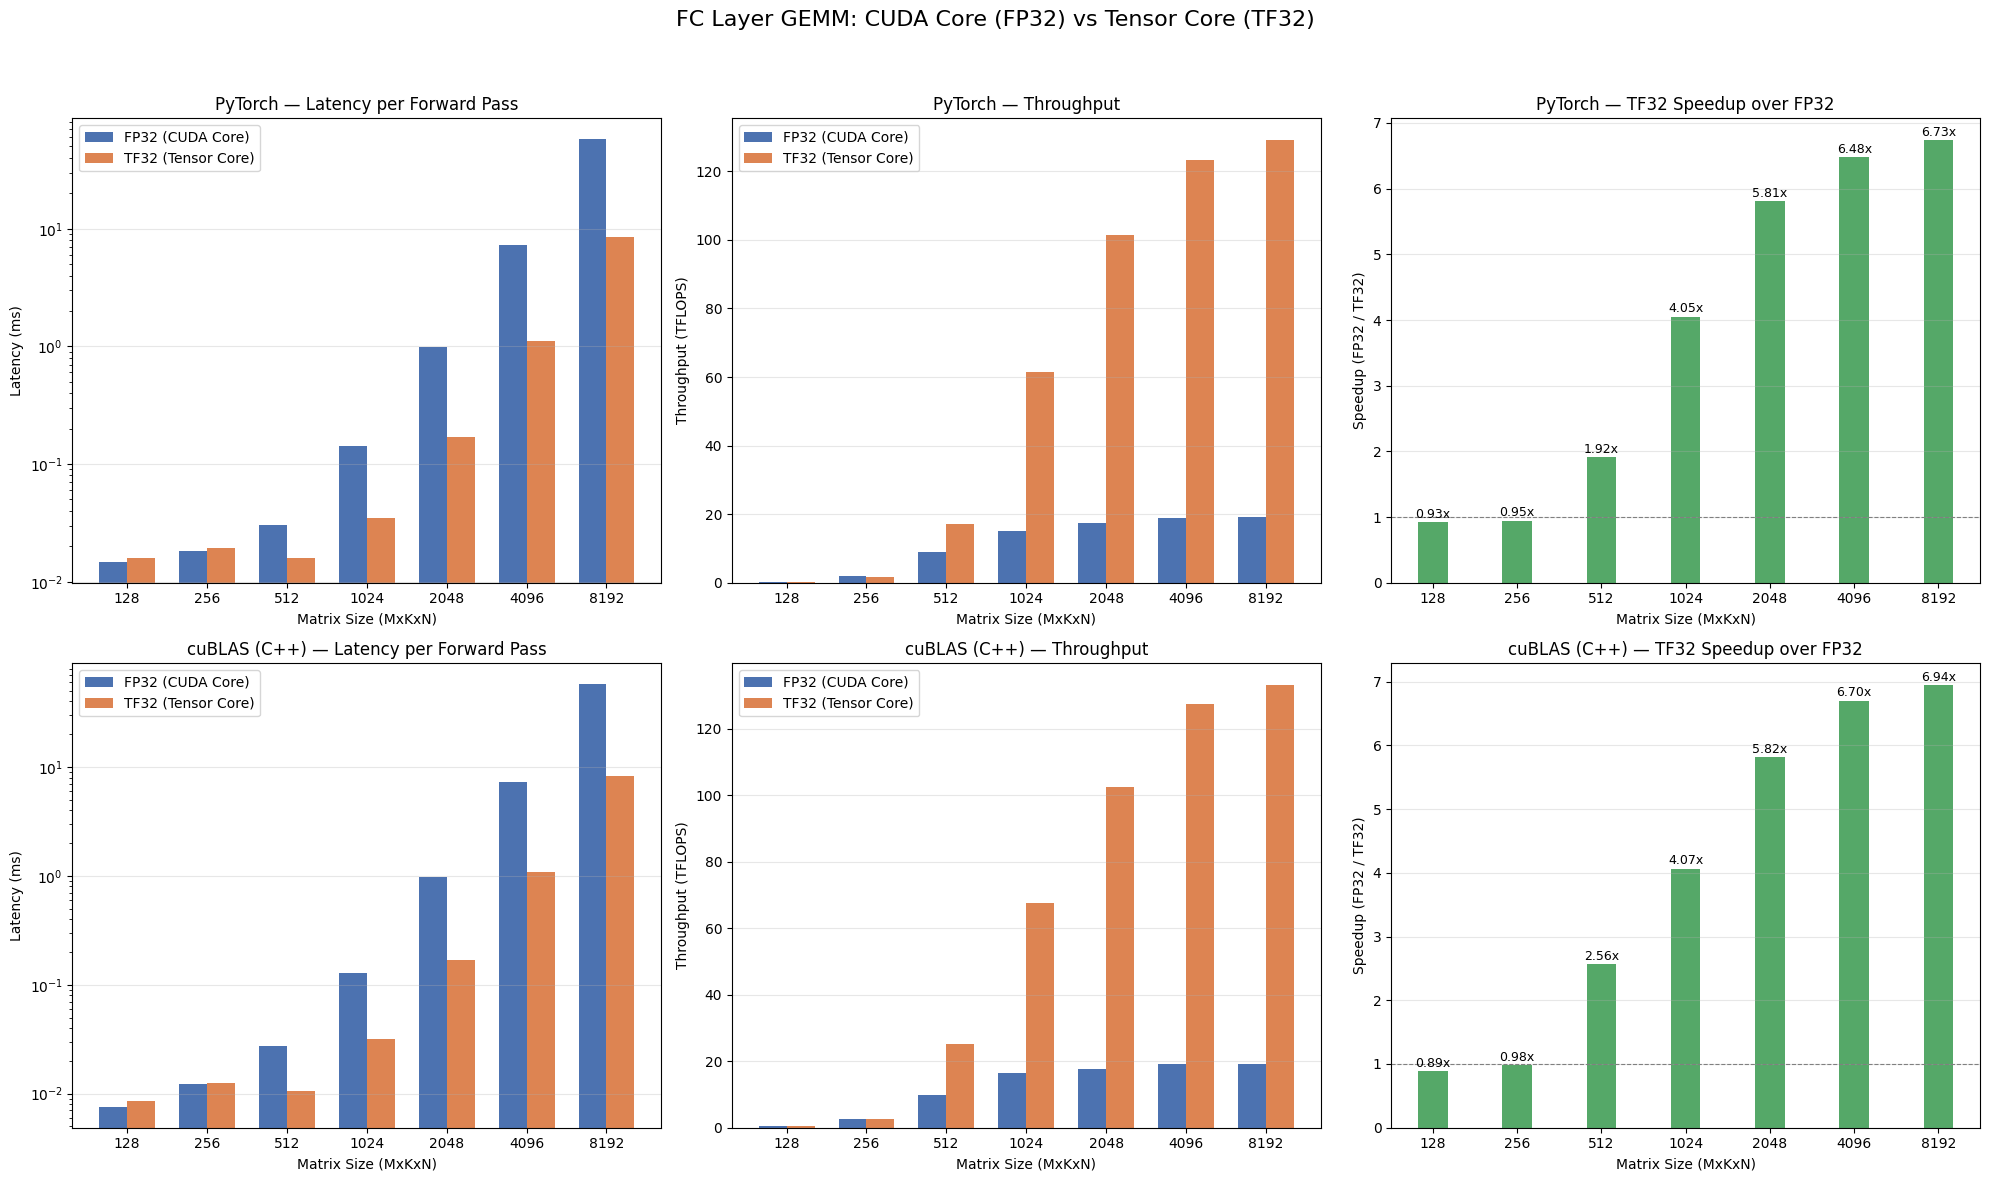

Plot saved to benchmark_plots.png


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import csv

def load_csv(path):
    rows = []
    with open(path, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append({k: float(v) for k, v in row.items()})
    return rows

pytorch_data = load_csv("results_pytorch.csv")
cublas_data = load_csv("results_cublas.csv")


def plot_framework(data, framework_name, ax_lat, ax_tput, ax_speedup):
    sizes = [int(r["M"]) for r in data]
    lat_fp32 = [r["latency_fp32_ms"] for r in data]
    lat_tf32 = [r["latency_tf32_ms"] for r in data]
    tflops_fp32 = [r["tflops_fp32"] for r in data]
    tflops_tf32 = [r["tflops_tf32"] for r in data]
    speedups = [r["speedup"] for r in data]

    x = np.arange(len(sizes))
    width = 0.35

    # Latency
    ax_lat.bar(x - width/2, lat_fp32, width, label="FP32 (CUDA Core)", color="#4C72B0")
    ax_lat.bar(x + width/2, lat_tf32, width, label="TF32 (Tensor Core)", color="#DD8452")
    ax_lat.set_xlabel("Matrix Size (MxKxN)")
    ax_lat.set_ylabel("Latency (ms)")
    ax_lat.set_title(f"{framework_name} — Latency per Forward Pass")
    ax_lat.set_xticks(x)
    ax_lat.set_xticklabels([str(s) for s in sizes])
    ax_lat.set_yscale("log")
    ax_lat.legend()
    ax_lat.grid(axis="y", alpha=0.3)

    # Throughput
    ax_tput.bar(x - width/2, tflops_fp32, width, label="FP32 (CUDA Core)", color="#4C72B0")
    ax_tput.bar(x + width/2, tflops_tf32, width, label="TF32 (Tensor Core)", color="#DD8452")
    ax_tput.set_xlabel("Matrix Size (MxKxN)")
    ax_tput.set_ylabel("Throughput (TFLOPS)")
    ax_tput.set_title(f"{framework_name} — Throughput")
    ax_tput.set_xticks(x)
    ax_tput.set_xticklabels([str(s) for s in sizes])
    ax_tput.legend()
    ax_tput.grid(axis="y", alpha=0.3)

    # Speedup
    ax_speedup.bar(x, speedups, width, color="#55A868")
    ax_speedup.axhline(y=1.0, color="gray", linestyle="--", linewidth=0.8)
    ax_speedup.set_xlabel("Matrix Size (MxKxN)")
    ax_speedup.set_ylabel("Speedup (FP32 / TF32)")
    ax_speedup.set_title(f"{framework_name} — TF32 Speedup over FP32")
    ax_speedup.set_xticks(x)
    ax_speedup.set_xticklabels([str(s) for s in sizes])
    ax_speedup.grid(axis="y", alpha=0.3)
    for i, v in enumerate(speedups):
        ax_speedup.text(i, v + 0.02, f"{v:.2f}x", ha="center", va="bottom", fontsize=9)


fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("FC Layer GEMM: CUDA Core (FP32) vs Tensor Core (TF32)", fontsize=16, y=0.98)

plot_framework(pytorch_data, "PyTorch", axes[0][0], axes[0][1], axes[0][2])
plot_framework(cublas_data, "cuBLAS (C++)", axes[1][0], axes[1][1], axes[1][2])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("benchmark_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to benchmark_plots.png")

---
## 5. Summary Table

In [7]:
import pandas as pd

print("=" * 80)
print("PyTorch Results")
print("=" * 80)
df_pt = pd.DataFrame(pytorch_results)
df_pt["size"] = df_pt["M"].astype(int).astype(str) + "x" + df_pt["K"].astype(int).astype(str)
df_pt = df_pt[["size", "latency_fp32_ms", "tflops_fp32", "latency_tf32_ms", "tflops_tf32", "speedup"]]
df_pt.columns = ["Size", "FP32 Lat (ms)", "FP32 TFLOPS", "TF32 Lat (ms)", "TF32 TFLOPS", "Speedup"]
display(df_pt.round(4))

print()
print("=" * 80)
print("cuBLAS (C++) Results")
print("=" * 80)
df_cb = pd.DataFrame(cublas_results)
df_cb["size"] = df_cb["M"].astype(int).astype(str) + "x" + df_cb["K"].astype(int).astype(str)
df_cb = df_cb[["size", "latency_fp32_ms", "tflops_fp32", "latency_tf32_ms", "tflops_tf32", "speedup"]]
df_cb.columns = ["Size", "FP32 Lat (ms)", "FP32 TFLOPS", "TF32 Lat (ms)", "TF32 TFLOPS", "Speedup"]
display(df_cb.round(4))

PyTorch Results


,Size,FP32 Lat (ms),FP32 TFLOPS,TF32 Lat (ms),TF32 TFLOPS,Speedup
0,128x128,0.0148,0.2830,0.0160,0.2620,0.9258
1,256x256,0.0183,1.8383,0.0193,1.7384,0.9456
2,512x512,0.0302,8.8772,0.0158,17.0003,1.9150
3,1024x1024,0.1417,15.1572,0.0350,61.4010,4.0509
4,2048x2048,0.9855,17.4331,0.1696,101.2995,5.8107
5,4096x4096,7.2276,19.0157,1.1147,123.2984,6.4840
6,8192x8192,57.3924,19.1578,8.5230,129.0047,6.7338



cuBLAS (C++) Results


,Size,FP32 Lat (ms),FP32 TFLOPS,TF32 Lat (ms),TF32 TFLOPS,Speedup
0,128x128,0.0076,0.5520,0.0085,0.4929,0.8929
1,256x256,0.0123,2.7352,0.0125,2.6903,0.9836
2,512x512,0.0274,9.8108,0.0107,25.1337,2.5618
3,1024x1024,0.1294,16.5914,0.0318,67.4868,4.0676
4,2048x2048,0.9746,17.6279,0.1676,102.5064,5.8150
5,4096x4096,7.2273,19.0166,1.0786,127.4205,6.7005
6,8192x8192,57.3717,19.1647,8.2666,133.0061,6.9402


---
## 6. Analysis & Discussion

### Key Observations

**What is TF32?**
- TF32 (TensorFloat-32) uses the range of FP32 (8 exponent bits) with reduced mantissa precision (10 bits vs 23 bits)
- Tensor Cores on Ampere (A100) can process TF32 operations at much higher throughput than FP32 CUDA cores
- A100 peak: 19.5 TFLOPS (FP32) vs 156 TFLOPS (TF32 Tensor Core) — up to 8x theoretical speedup

**Expected results:**
1. **Small matrices (128-512):** Minimal speedup — kernel launch overhead dominates, and the matrix is too small to saturate Tensor Cores
2. **Medium matrices (1024-2048):** Moderate speedup — Tensor Cores begin to show advantage as compute intensity grows
3. **Large matrices (4096-8192):** Maximum speedup — compute-bound regime where Tensor Cores deliver near-peak throughput advantage

**Why the speedup is less than theoretical 8x:**
- Memory bandwidth limits (not purely compute-bound at all sizes)
- cuBLAS kernel selection heuristics
- Overhead from data format conversion
- Not all operations in the pipeline use Tensor Cores

**PyTorch vs cuBLAS:**
- PyTorch internally calls cuBLAS, so results should be similar
- PyTorch may have slight overhead from its dispatch/autograd layer
- The TF32 speedup ratio should be comparable between both implementations

---
## 7. Download Results

In [8]:
from google.colab import files

files.download("results_pytorch.csv")
files.download("results_cublas.csv")
files.download("benchmark_plots.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>